In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.3 MB/s eta 0:00:00


Dataset Preview
   CustomerID      PartName   Brand  Quantity     TransactionTime  \
0       89706      Electric  BrandD         1 2019-01-01 00:00:00   
1       65033          Body  BrandB         2 2019-01-01 00:01:00   
2       51029  Transmission  BrandC         9 2019-01-01 00:02:00   
3       23938  Transmission  BrandC         4 2019-01-01 00:03:00   
4       26133      Exterior  BrandC         5 2019-01-01 00:04:00   

   MonetaryValue  Recency  Frequency  Monetary  Length        CQ        CD  \
0         490.46        4          4   9416.99      25  4.853005  3.800906   
1        1261.26       45         12   6733.09      11  2.819825  2.700571   
2        1596.90       13          6   8661.83       5  2.966381  3.239202   
3        3305.53       14         17   9724.62       9  3.991093  1.171522   
4        1027.57       37         13  13361.45      25  3.022770  1.244361   

         CS     S  
0  4.908560  4.52  
1  2.354490  2.62  
2  3.477184  3.23  
3  3.145876  2.77  


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

Model Performance
           Model       MSE       MAE      RMSE        R2
0  Random Forest  0.005414  0.057259  0.073579  0.989208
1       CatBoost  0.000651  0.019876  0.025506  0.998703
2           LSTM  0.031818  0.141704  0.178375  0.936577
3            GRU  0.003341  0.045185  0.057799  0.993341


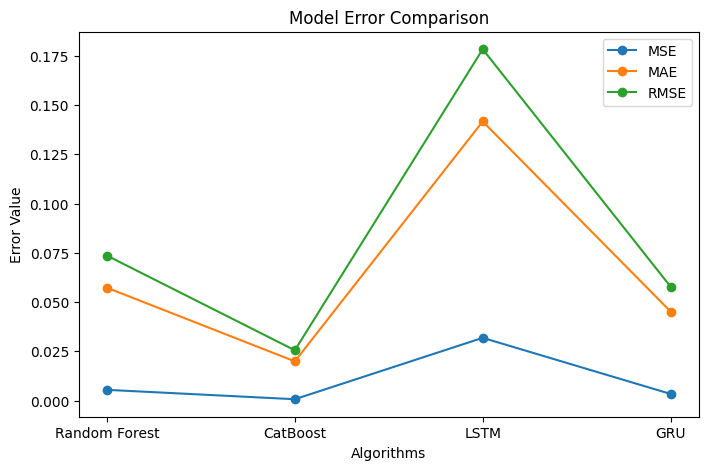

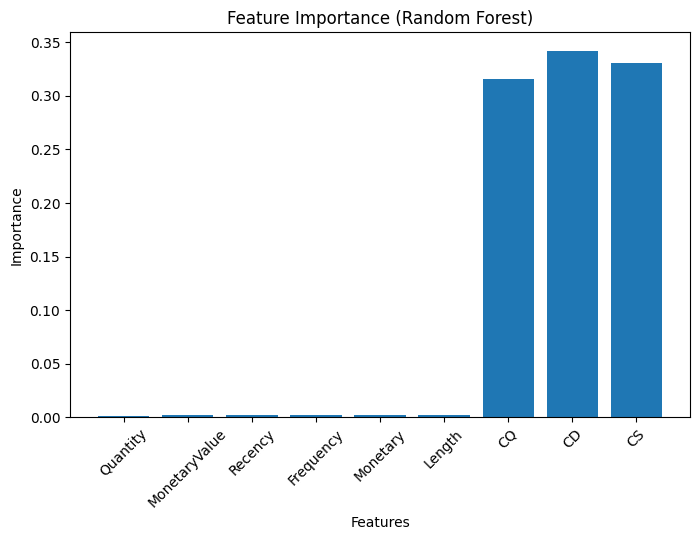

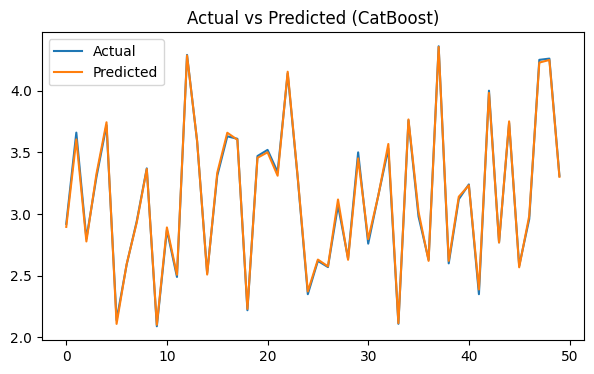

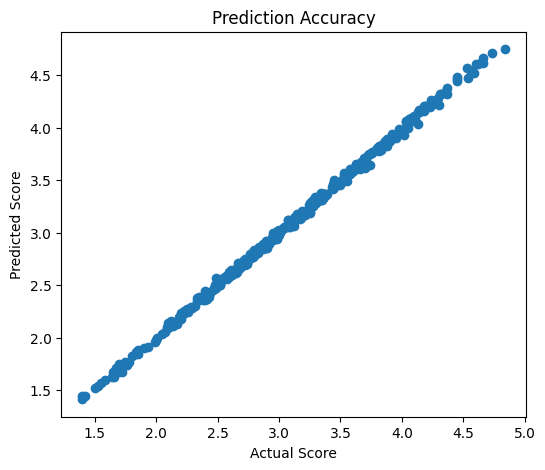

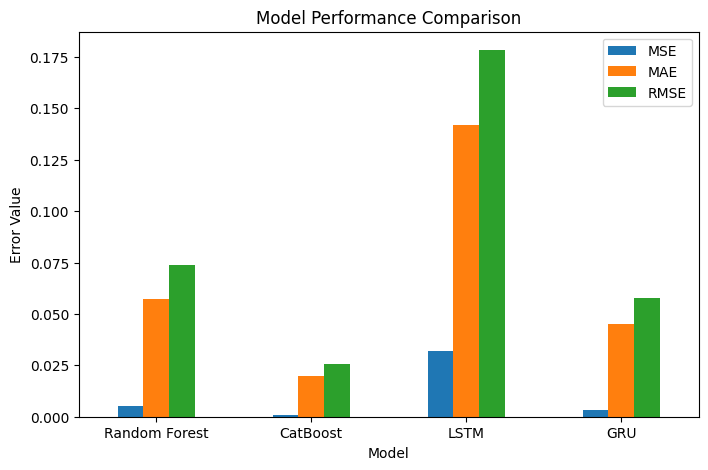

In [ ]:
# ==============================
# 1 IMPORT LIBRARIES
# ==============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense


# ==============================
# 2 LOAD DATASET
# ==============================

df = pd.read_excel('/content/finalproject.xlsx')

print("Dataset Preview")
print(df.head())


# ==============================
# 3 DATA PREPROCESSING
# ==============================

# Remove non-numeric columns
df = df.drop(columns=['CustomerID','PartName','Brand','TransactionTime'])

# Target variable
X = df.drop(columns=['S'])
y = df['S']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ==============================
# 4 RANDOM FOREST MODEL
# ==============================

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)


# ==============================
# 5 CATBOOST MODEL
# ==============================

cat = CatBoostRegressor(
    iterations=300,
    learning_rate=0.1,
    depth=6,
    verbose=0
)

cat.fit(X_train, y_train)

cat_pred = cat.predict(X_test)


# ==============================
# 6 PREPARE DATA FOR DEEP LEARNING
# ==============================

X_train_dl = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test_dl = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)


# ==============================
# 7 LSTM MODEL
# ==============================

lstm_model = Sequential()

lstm_model.add(LSTM(50, input_shape=(X_train_dl.shape[1],1)))

lstm_model.add(Dense(1))

lstm_model.compile(
    optimizer='adam',
    loss='mse'
)

lstm_model.fit(
    X_train_dl,
    y_train,
    epochs=20,
    batch_size=32,
    verbose=0
)

lstm_pred = lstm_model.predict(X_test_dl).flatten()


# ==============================
# 8 GRU MODEL
# ==============================

gru_model = Sequential()

gru_model.add(GRU(50, input_shape=(X_train_dl.shape[1],1)))

gru_model.add(Dense(1))

gru_model.compile(
    optimizer='adam',
    loss='mse'
)

gru_model.fit(
    X_train_dl,
    y_train,
    epochs=20,
    batch_size=32,
    verbose=0
)

gru_pred = gru_model.predict(X_test_dl).flatten()


# ==============================
# 9 EVALUATION FUNCTION
# ==============================

def evaluate(y_true, y_pred):

    mse = mean_squared_error(y_true, y_pred)

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_true, y_pred)

    return mse, mae, rmse, r2


rf_metrics = evaluate(y_test, rf_pred)
cat_metrics = evaluate(y_test, cat_pred)
lstm_metrics = evaluate(y_test, lstm_pred)
gru_metrics = evaluate(y_test, gru_pred)


# ==============================
# 10 RESULTS TABLE
# ==============================

results = pd.DataFrame({

'Model':['Random Forest','CatBoost','LSTM','GRU'],

'MSE':[rf_metrics[0],cat_metrics[0],lstm_metrics[0],gru_metrics[0]],

'MAE':[rf_metrics[1],cat_metrics[1],lstm_metrics[1],gru_metrics[1]],

'RMSE':[rf_metrics[2],cat_metrics[2],lstm_metrics[2],gru_metrics[2]],

'R2':[rf_metrics[3],cat_metrics[3],lstm_metrics[3],gru_metrics[3]]

})

print("\nModel Performance")
print(results)


# ==============================
# 11 LINE GRAPH COMPARISON
# ==============================

plt.figure(figsize=(8,5))

plt.plot(results['Model'],results['MSE'],marker='o',label='MSE')

plt.plot(results['Model'],results['MAE'],marker='o',label='MAE')

plt.plot(results['Model'],results['RMSE'],marker='o',label='RMSE')

plt.title("Model Error Comparison")

plt.xlabel("Algorithms")

plt.ylabel("Error Value")

plt.legend()

plt.show()


# ==============================
# 12 FEATURE IMPORTANCE
# ==============================

importance = rf.feature_importances_

features = X.columns

plt.figure(figsize=(8,5))

plt.bar(features, importance)

plt.title("Feature Importance (Random Forest)")

plt.xlabel("Features")

plt.ylabel("Importance")

plt.xticks(rotation=45)

plt.show()


# ==============================
# 13 ACTUAL VS PREDICTED LINE GRAPH
# ==============================

plt.figure(figsize=(7,4))

plt.plot(y_test.values[:50],label="Actual")

plt.plot(cat_pred[:50],label="Predicted")

plt.title("Actual vs Predicted (CatBoost)")

plt.legend()

plt.show()


# ==============================
# 14 SCATTER PLOT
# ==============================

plt.figure(figsize=(6,5))

plt.scatter(y_test, cat_pred)

plt.xlabel("Actual Score")

plt.ylabel("Predicted Score")

plt.title("Prediction Accuracy")

plt.show()


# ==============================
# 15 BAR CHART COMPARISON
# ==============================

results.set_index('Model')[['MSE','MAE','RMSE']].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Model Performance Comparison")

plt.ylabel("Error Value")

plt.xticks(rotation=0)

plt.show()